# Churn Prediction
Shortcut to run all blocks: ESC, CTRL + A, SHIFT + ENTER

## Imports

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

## Dataset Info

In [168]:
CSV_FILE = "Churn_Modelling.csv"
TARGET = "Exited"
UNNECESSARY_FEATURES = ["RowNumber", "CustomerId", "Surname"]
NOMINAL_FEATURES = ["Surname", "Geography", "Gender"]
SELECTED_NOMINAL_FEATURES = list(set(NOMINAL_FEATURES) - set(UNNECESSARY_FEATURES))
RANDOM_STATE = 42

data_frame = pd.read_csv(CSV_FILE)
data_frame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Dataset Statistics

In [169]:
data_frame.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## No Values Missing

In [170]:
data_frame.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Display Target Class Imbalance

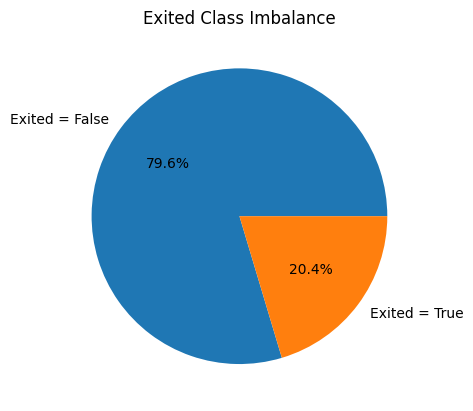

In [171]:
# https://wellsr.com/python/upsampling-and-downsampling-imbalanced-data-in-python/
def frame_target_imbalance(df):
    df.groupby(TARGET).size().plot(kind="pie", y=TARGET, title=f"{TARGET} Class Imbalance", labels=[f"{TARGET} = False", f"{TARGET} = True"], autopct="%1.1f%%")

frame_target_imbalance(data_frame)

## Temporarily Label Encode Selected Nominal Features
This is temporarily done so these features will be shown on the box plot. Using the dataset with Nominal Features being Label Encoded is bad practice because a model might think there is some order to the Nominal Features when there isn't one in reality. We will transform the data frame to use One-hot encoding before training and testing. For more information, see https://stackoverflow.com/questions/36631163/what-are-the-pros-and-cons-between-get-dummies-pandas-and-onehotencoder-sciki. Finally, note that One-hot encoding led to an improvement in the Decision Tree's performance below.

In [172]:
label_encoder = LabelEncoder()
for nominal_feature in SELECTED_NOMINAL_FEATURES:
    current_feature_values = data_frame[nominal_feature]
    label_encoder.fit(current_feature_values)
    data_frame[nominal_feature] = label_encoder.transform(current_feature_values)
data_frame.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## Feature Removal

In [173]:
data_frame = data_frame.drop(columns=UNNECESSARY_FEATURES)
data_frame.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## Show Unscaled Features

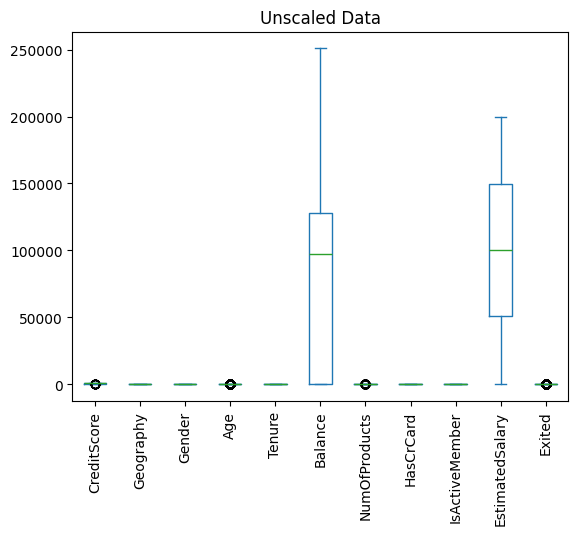

In [174]:
def frame_box_plot(df, title):
    df.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

frame_box_plot(data_frame, "Unscaled Data")

## One-hot Encoding
**TODO**: Should we set drop_first=True for certain models? See https://datascience.stackexchange.com/questions/47638/in-which-cases-shouldnt-we-drop-the-first-level-of-categorical-variables for more information.

In [175]:
data_frame = pd.get_dummies(data_frame, columns=SELECTED_NOMINAL_FEATURES, drop_first=False)
data_frame.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_0,Gender_1,Geography_0,Geography_1,Geography_2
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,True,False,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,True,False,False,False,True


## Show Correlation Among Features

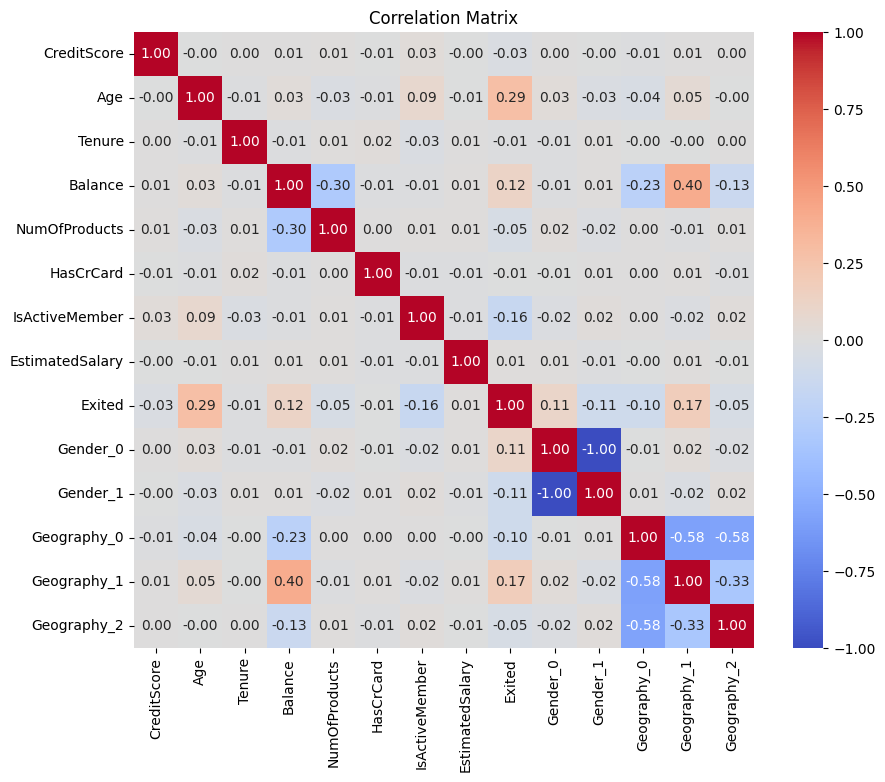

In [176]:
def frame_correlation_matrix(df):
    correlation_matrix = df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

frame_correlation_matrix(data_frame)

## Define Unscaled Features and Target

In [177]:
def get_x_y(df):
    x = df.drop(columns=[TARGET])
    y = df[TARGET]
    return x, y

x, y = get_x_y(data_frame)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_0,Gender_1,Geography_0,Geography_1,Geography_2
0,619,42,2,0.00,1,1,1,101348.88,True,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,True,False,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,True,False,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,True,False,False,False,True


## Define Target

In [178]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

## Define Function for Testing Models

In [179]:
def test_model(model):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, train_size=0.8, random_state=RANDOM_STATE, stratify=y)
    model.fit(x_train, y_train)
    y_test_predicted = model.predict(x_test)
    
    print(classification_report(y_test, y_test_predicted))
    return model

## Test Decision Tree

In [180]:
test_model(DecisionTreeClassifier(random_state=RANDOM_STATE))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1593
           1       0.48      0.50      0.49       407

    accuracy                           0.79      2000
   macro avg       0.67      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000



DecisionTreeClassifier(random_state=42)